# 03_集成算法-Bagging算法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天聊的主题是：**Bagging**。

简单来说，**Bagging**（Bootstrap Aggregating）是一种集成学习方法，通过构建多个相互独立的基学习器并将其预测结果结合起来，从而提升模型的整体性能。

Bagging主要用于减少模型的方差，提高稳定性，防止过拟合。

Bagging核心步骤：

1. 从训练数据集中使用**自助采样法（Bootstrap Sampling）**生成多个子数据集（每个子数据集通过有放回随机采样获得，大小与原始数据集相同）。
2. 在每个子数据集上训练一个基学习器（通常是同种模型，如决策树）。
3. 对于分类任务，使用**投票法**聚合基学习器的预测；对于回归任务，使用**平均法**聚合预测结果。

经典的Bagging算法包括**随机森林**，它通过使用决策树作为基学习器，并在选择特征时引入随机性，进一步增强模型的性能。

Bagging的核心思想可以用一个简单的比喻来说明：

假设你在做一件重要决定，比如买房子，自己也拿不定主意，于是你找了10个朋友帮忙。每个朋友都有不同的背景和看问题的方式（相当于基学习器），他们会根据部分信息（相当于子数据集）各自独立地给出建议。最后，你综合大家的意见（比如投票或取平均值）来做决定。这样，即使个别朋友的意见不太靠谱，总体来说还是能得到一个相对稳妥的结果。

Bagging的优势在于：

- **减少波动**：即使某个基学习器有偏差，它不会对整体结果造成太大影响，因为我们取的是综合意见。
- **增强稳定性**：通过引入随机性（子数据集、随机特征选择等），模型可以更好地适应数据变化，不容易过拟合。

**Bagging就是用“多次抽样+独立训练+综合投票”这种方法，让模型不容易偏离真实情况，表现更稳健！**

## 理论基础

### 数学原理

**1. 自助采样（Bootstrap Sampling）**

给定一个包含 $N$个样本的数据集 $D = \{(x_1, y_1), (x_2, y_2), \dots, (x_N, y_N)\}$，通过有放回随机采样的方法，从 $D$中生成 $m$个子数据集 $D_1, D_2, \dots, D_m$，其中每个子数据集的大小也为 $N$。

由于是**有放回采样**，一个样本可能多次出现在同一个子数据集中，或者完全不出现。理论上，每个子数据集中大约包含 $63.2\%$的原始数据（即 $1 - e^{-1}$）。

**2. 基学习器的独立训练**

对于每个子数据集 $D_i$，训练一个基学习器 $h_i(x)$。这些基学习器是独立的，通常使用同样的算法（如决策树）。

**3. 集成预测（Ensemble Prediction）**

- **分类任务**：使用多数投票法。给定测试样本 $x$，所有基学习器的预测结果为 $\{h_1(x), h_2(x), \dots, h_m(x)\}$，最终的分类结果是预测类别中票数最多的类别：  
$H(x) = \underset{y}{\text{argmax}} \sum_{i=1}^{m} \mathbb{I}(h_i(x) = y),$  
其中 $\mathbb{I}(\cdot)$是指示函数，当条件为真时取值 1，否则为 0。
- **回归任务**：使用简单平均法。给定测试样本 $x$，所有基学习器的预测结果为 $\{h_1(x), h_2(x), \dots, h_m(x)\}$，最终的预测结果为：  
$H(x) = \frac{1}{m} \sum_{i=1}^{m} h_i(x).$

**4. 减少方差的原理**

Bagging通过集成学习降低模型的方差。设单个基学习器的预测为 $h(x)$，其误差可以分解为偏差和方差：  
$\text{MSE} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}.$  
对于 Bagging 的集成模型，若基学习器相互独立，方差可以通过集成降低：


$$
\text{Var}(H(x)) = \frac{1}{m} \text{Var}(h(x)),
$$


其中 $m$是基学习器的数量。

### 算法流程

**1. 输入**：

- 训练数据集 $D = \{(x_1, y_1), (x_2, y_2), \dots, (x_N, y_N)\}$；
- 基学习器数量 $m$；
- 基学习算法 $A$。

**2. 生成子数据集**：

- 通过**有放回随机采样**的方法，从 $D$中生成 $m$个子数据集 $D_1, D_2, \dots, D_m$。
- 每个子数据集 $D_i$的大小为 $N$。

**3. 训练基学习器**：

- 对每个子数据集 $D_i$：

  - 使用基学习算法 $A$训练一个基学习器 $h_i(x)$。

**4. 集成预测**：

- **分类任务**：

  - 对于每个测试样本 $x$，收集所有基学习器的预测 $\{h_1(x), h_2(x), \dots, h_m(x)\}$；
  - 使用多数投票法计算最终预测结果：  
  $H(x) = \underset{y}{\text{argmax}} \sum_{i=1}^{m} \mathbb{I}(h_i(x) = y).$
- **回归任务**：

  - 对于每个测试样本 $x$，收集所有基学习器的预测 $\{h_1(x), h_2(x), \dots, h_m(x)\}$；
  - 使用简单平均法计算最终预测结果：  
  $H(x) = \frac{1}{m} \sum_{i=1}^{m} h_i(x).$

**5. 输出**：

- 集成模型 $H(x)$。

Bagging通过“数据扰动”和“模型集成”降低方差，是一种简单而有效的集成学习方法。其代表算法**随机森林**在各种场景中被广泛应用。

## 完整案例

以下**Bagging算法**适用于分类任务。其中代码生成虚拟数据集，应用Bagging算法，并可视化数据分布和分类结果。

我们使用**Scikit-learn**中的`BaggingClassifier`结合`DecisionTreeClassifier`作为基学习器。

Training Accuracy: 0.91
Testing Accuracy: 0.90


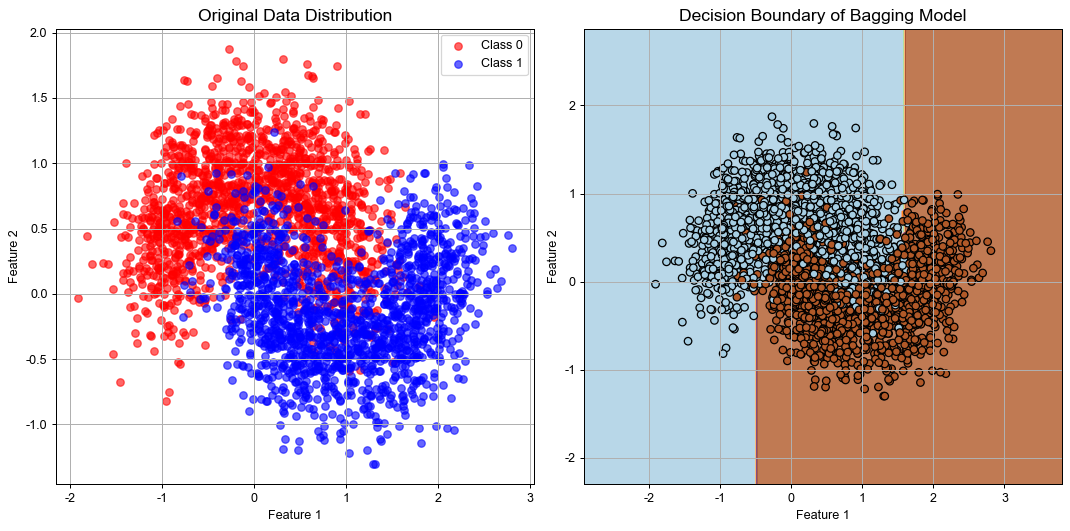

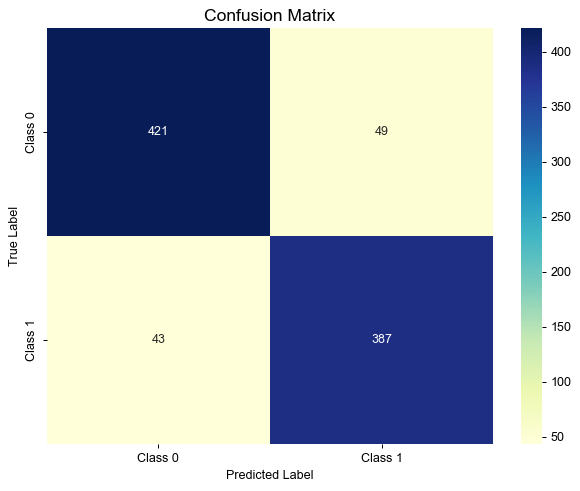

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# Step 1: 生成虚拟数据集
np.random.seed(42)
X, y = make_moons(n_samples=3000, noise=0.3, random_state=42)

# 数据集划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 2: 构建 Bagging 模型
estimator = DecisionTreeClassifier(max_depth=5, random_state=42)
bagging_model = BaggingClassifier(estimator=estimator, n_estimators=50, max_samples=0.8, random_state=42)

# 训练模型
bagging_model.fit(X_train, y_train)

# 预测
y_pred_train = bagging_model.predict(X_train)
y_pred_test = bagging_model.predict(X_test)

# Step 3: 性能评估
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

# Step 4: 数据可视化
# 可视化数据分布
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Data Distribution", fontsize=14)
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0', alpha=0.6)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1', alpha=0.6)
plt.legend()
plt.grid(True)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# 可视化决策边界
def plot_decision_boundary(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Paired)
    plt.title(title, fontsize=14)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)

plt.subplot(1, 2, 2)
plot_decision_boundary(bagging_model, X, y, "Decision Boundary of Bagging Model")

plt.tight_layout()
plt.show()

# Step 5: 可视化混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="YlGnBu", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**代码优化方面：**

1. **模型参数优化**：增加基学习器数量：`n_estimators=100` 或更高。调整基学习器的深度：通过`max_depth`控制过拟合。采样比例：`max_samples`和`max_features`进行搜索以提高泛化能力。
2. **性能评估**：使用交叉验证评估模型。可以增加指标，如F1-score、ROC曲线等。
3. **数据处理**：如果是实际问题数据，考虑标准化、特征选择、以及处理不均衡类别。

### 结果分析

**1. 数据分布图**：图1显示了原始数据的分布情况（两个类别的混合分布）。图2显示了Bagging模型对数据的决策边界。

![原文参考图，当前结果见代码输出](attachments/img_035.png)

**2. 混淆矩阵**：用于展示预测的准确性和错误分类情况。

![原文参考图，当前结果见代码输出](attachments/img_036.png)

**3. 准确率**：打印训练集和测试集的准确率，验证Bagging模型的性能。

原文参考输出（实际结果以上方运行输出为准）：

```text
Training Accuracy: 0.91
Testing Accuracy: 0.90
```

整个代码展示了Bagging的一个经典案例，适用于理解算法的核心思想及其在分类问题中的效果。

## 应用场景

**1. 适用场景**：

- **高方差模型**：适用于对输入数据变化敏感的模型（如决策树、神经网络等）。
- **非线性问题**：在非线性关系较复杂的问题中表现优异。
- **小数据集问题**：通过自助采样（Bootstrap）模拟数据多样性。
- **分类与回归问题**：均可使用，分类任务通过多数投票，回归任务通过取均值实现预测。

**2. 不适合场景**：

- **低方差高偏差模型**：如线性回归、支持向量机，这些模型本身偏差高，Bagging不能明显改进性能。
- **对实时性要求高的场景**：由于需要训练多个基学习器，训练与预测时间会增加。

### 优缺点

**优点**：

1. **减少方差**：通过集成降低单个模型预测的波动，提升模型稳定性。
2. **抗过拟合**：通过子样本随机采样引入噪声，减小过拟合的风险。
3. **提高准确性**：相比单一模型，集成模型的总体准确性通常更高。
4. **可并行化**：基学习器之间是独立训练的，支持并行计算，提升效率。

**缺点**：

1. **计算开销大**：需要训练多个模型，增加训练时间和计算资源。
2. **对弱基学习器依赖强**：Bagging更适合方差较高的弱模型，对强模型效果有限。
3. **解释性较差**：集成模型难以解释每个基学习器的作用，尤其当基学习器数量较多时。

### 运用时的前提条件

1. **基学习器的独立性**：基学习器之间需要尽可能独立，避免相同的错误模式。
2. **模型的高方差**：Bagging对高方差模型更有效果，建议选择如决策树这样的不稳定模型。
3. **数据规模适中**：需要足够多的数据保证子采样的多样性，但如果数据量太大可能增加计算负担。

### 实际中的应用案例

1. **随机森林（Random Forest）**：

   - 在分类问题中，如垃圾邮件过滤（判断邮件是否为垃圾邮件）、图片分类（识别猫狗）。
   - 在回归问题中，如房价预测、股票价格预测。
2. **金融风险预测**：

   - 使用Bagging算法对客户违约概率进行分类预测，通过集成多个决策树提高预测的鲁棒性。
3. **医疗诊断**：

   - 用于疾病诊断中，通过不同子模型对疾病是否存在进行判断（分类），如预测癌症是否复发。
4. **客户流失分析**：

   - 在电商和通信行业，Bagging模型通过客户历史行为数据，预测客户是否会停止使用服务。
5. **机器学习竞赛**：

   - 在Kaggle或其他机器学习比赛中，Bagging常作为提升模型性能的基础工具，与其他方法（如Boosting）结合使用。

## 总结

Bagging算法通过降低方差和集成预测增强模型性能，在非线性问题、分类和回归任务中广泛应用。其代表性实现**随机森林**在图像处理、医疗诊断、金融分析等领域表现突出。